# Reconstructing HELENA files from a data sample

This notebook demonstrates how to reconstruct a `fort.10` input file from a
sample HDF5 file.

The reconstructed file can be used to rerun HELENA, making each HDF5 sample a
self-contained representation of an equilibrium.

In [31]:
from pathlib import Path
import f90nml

from karhu_data_handling.convert_sample import convert_sample, recreate_fort10

In [32]:
sample_dir = Path("..\\tests\\data\\HelenaRunner-0a8221be-38f7-4679-a937-566e6bf83d5a_scan_2")
sample_file = Path("..\\tests\\data\\sample.h5")

original_fort10 = Path("..\\tests\\data\\HelenaRunner-0a8221be-38f7-4679-a937-566e6bf83d5a_scan_2\\fort.10")
original_fort12 = Path("..\\tests\\data\\HelenaRunner-0a8221be-38f7-4679-a937-566e6bf83d5a_scan_2\\fort.12")
original_fort14 = Path("..\\tests\\data\\HelenaRunner-0a8221be-38f7-4679-a937-566e6bf83d5a_scan_2\\fort.14")

output_fort10 = Path("fort.10.reconstructed")
output_fort12 = Path("fort.12.reconstructed")
output_fort14 = Path("fort.14.reconstructed")

## Create sample

In [33]:
convert_sample(sample_dir=sample_dir, output_file=sample_file)

300 75 76
513 129 38475
Saved ..\tests\data\sample.h5


## Recreate fort.10 from sample

In [34]:
recreate_fort10(sample_file, output_fort10)

fort.10 written to fort.10.reconstructed


In [35]:
nml = f90nml.read(output_fort10)

print("Namelists:")
for name in nml:
    print(f"  {name}")

Namelists:
  ball
  num
  phys
  plot
  pri
  profile
  shape


In [36]:
import h5py

with h5py.File(sample_file, "r") as h5:
    inputs = h5["equilibrium"]["inputs"]
    print("Stored namelists:")

    for name in inputs:
        print(f"  {name}")

Stored namelists:
  ball
  num
  phys
  plot
  pri
  profile
  shape


In [37]:
from pathlib import Path
import f90nml
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


def flatten_namelist(nml, prefix=""):
    """
    Flatten a nested f90nml.Namelist into a dictionary.

    Keys are of the form:
        physics.beta
        shape.tria
        ...
    """
    result = {}

    for group_name, group in nml.items():
        for key, value in group.items():
            result[f"{group_name}.{key}"] = value

    return result


original = flatten_namelist(f90nml.read(original_fort10))
recreated = flatten_nml = flatten_namelist(f90nml.read(output_fort10))

# Union of all keys
keys = sorted(set(original) | set(recreated))

rows = []

for key in keys:
    rows.append({
        "Parameter": key,
        "Original": original.get(key),
        "Recreated": recreated.get(key),
        "Match": original.get(key) == recreated.get(key)
    })

comparison = pd.DataFrame(rows)

display(comparison)

,Parameter,Original,Recreated,Match
0,num.amix,0.0,0.0,True
1,num.errcur,0.0,0.0,True
2,num.nchi,513,513,True
3,num.niter,50,50,True
4,num.nmesh,100,100,True
5,num.np,129,129,True
6,num.npcur,33,33,True
7,num.npmap,513,513,True
8,num.nr,301,301,True
9,num.nrcur,150,150,True


The reconstructed `fort.10` is functionally equivalent to the original input
file. While formatting, comments, and whitespace may differ, all namelists and
parameter values are preserved in the HDF5 sample.

This enables complete reconstruction of the HELENA input from the archived data
without requiring access to the original simulation directory.

## Recreate fort.12 from sample

In [38]:
from karhu_data_handling.helena_equilibrium import (
    read_h5_equilibrium_profiles,
    write_helena_f12_data,
    read_helena_f12_data,
    FORT12_VARIABLES,
)

# Recreate fort.12 from the sample
data = read_h5_equilibrium_profiles(sample_file)
write_helena_f12_data(output_fort12, data)

# Read original and recreated files
original = read_helena_f12_data(original_fort12, FORT12_VARIABLES)
recreated = read_helena_f12_data(output_fort12, FORT12_VARIABLES)

Writing JS0 (scalar_int) [] 
Writing CS (array) ['JS0+1'] 301
Writing QS (array) ['JS0+1'] 301
Writing ('DQS_1', 'DQEC') (pair) [] 
Writing DQS (array) ['JS0'] 300
Writing CURJ (array) ['JS0+1'] 301
Writing ('DJ0', 'DJE') (pair) [] 
Writing NCHI (scalar_int) [] 
Writing CHI (array) ['NCHI'] 513
Writing GEM11 (array) ['NCHI_JS0'] 153900
Writing GEM12 (array) ['NCHI_JS0'] 153900
Writing ('CPSURF', 'RADIUS') (pair) [] 
Writing GEM33 (array) ['NCHI_JS0'] 153900
Writing RAXIS (scalar) [] 
Writing P0 (array) ['JS0+1'] 301
Writing ('DP0', 'DPE') (pair) [] 
Writing RBPHI (array) ['JS0+1'] 301
Writing ('DRBPHI0', 'DRBPHIE') (pair) [] 
Writing VX (array) ['NCHI'] 513
Writing VY (array) ['NCHI'] 513
Writing EPS (scalar) [] 
Writing XOUT (array) ['NCHI_JS0'] 153900
Writing YOUT (array) ['NCHI_JS0'] 153900
300 75 76
513 129 38475
300 75 76
513 129 38475


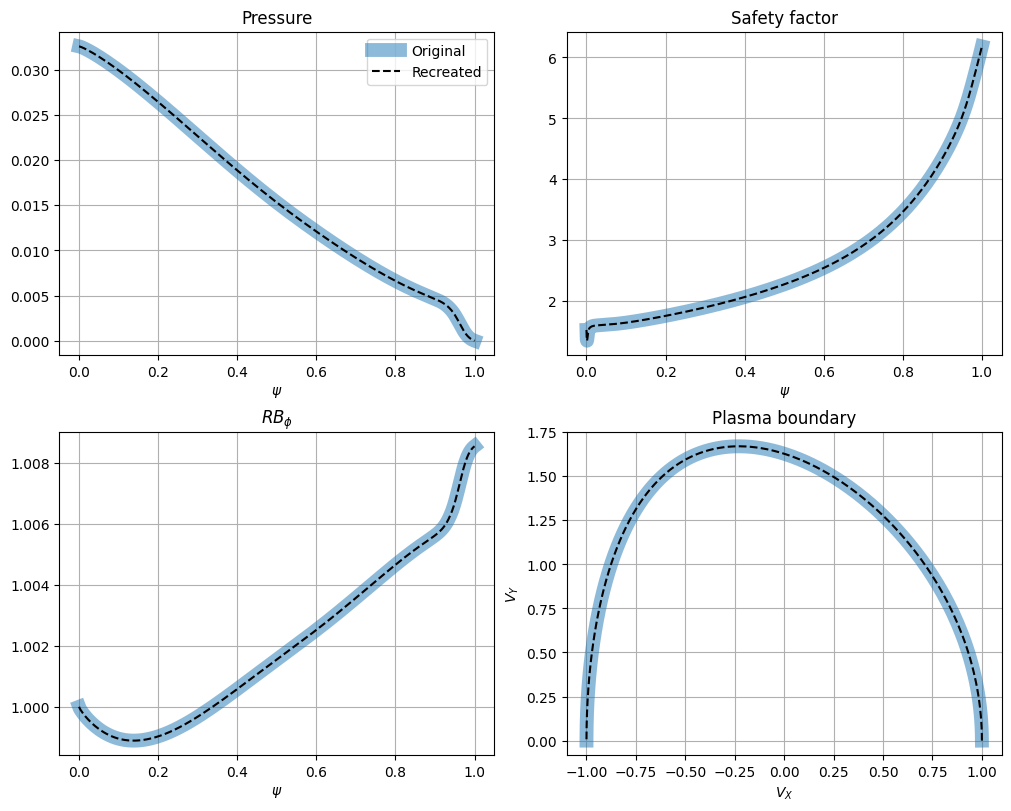

In [39]:
import matplotlib.pyplot as plt

s = original["CS"]
psi = s**2

profiles = [
    ("P0", "Pressure"),
    ("QS", "Safety factor"),
    ("RBPHI", r"$RB_\phi$"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

for ax, (key, title) in zip(axes.flat, profiles):

    ax.plot(psi, original[key], label="Original", lw=10, alpha=0.5)
    ax.plot(psi, recreated[key], "--", color="black", label="Recreated", lw=1.5)

    ax.set_title(title)
    ax.set_xlabel(r"$\psi$")
    ax.grid(True)

axes[1, 1].plot(original["VX"], original["VY"], label="Original", lw=10, alpha=0.5)
axes[1, 1].plot(recreated["VX"], recreated["VY"], "--", color="black", label="Recreated", lw=1.5)
axes[1, 1].set_title("Plasma boundary")
axes[1, 1].set_xlabel(r"$V_X$")
axes[1, 1].set_ylabel(r"$V_Y$")
axes[1, 1].grid(True)
axes[0, 0].legend()
plt.show()

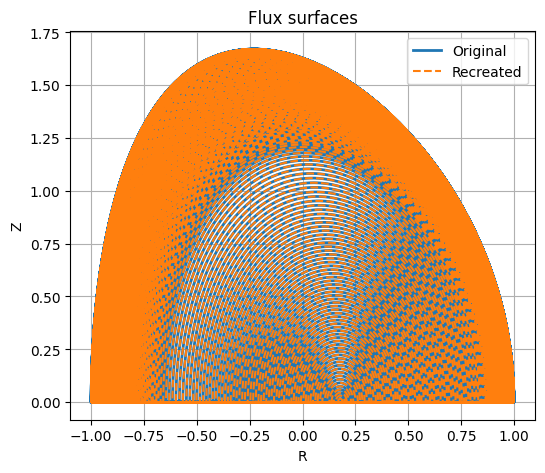

In [40]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(
    original["XOUT"],
    original["YOUT"],
    label="Original",
    lw=2,
)

ax.plot(
    recreated["XOUT"],
    recreated["YOUT"],
    "--",
    label="Recreated",
    lw=1.5,
)

ax.set_aspect("equal")
ax.set_xlabel("R")
ax.set_ylabel("Z")
ax.set_title("Flux surfaces")
ax.grid(True)
ax.legend()

plt.show()

In [41]:
import numpy as np

print("Maximum absolute differences")

for key in FORT12_VARIABLES:

    a = np.asarray(original[key])
    b = np.asarray(recreated[key])

    if a.shape == () or a.size == 1:
        diff = abs(float(a) - float(b))
    else:
        diff = np.max(np.abs(a - b))

    print(f"{key:10s}: {diff:.3e}")

Maximum absolute differences
JS0       : 0.000e+00
CS        : 0.000e+00
QS        : 0.000e+00
DQS_1     : 0.000e+00
DQEC      : 0.000e+00
DQS       : 0.000e+00
CURJ      : 0.000e+00
DJ0       : 0.000e+00
DJE       : 0.000e+00
NCHI      : 0.000e+00
CHI       : 0.000e+00
GEM11     : 0.000e+00
GEM12     : 0.000e+00
CPSURF    : 0.000e+00
RADIUS    : 0.000e+00
GEM33     : 0.000e+00
RAXIS     : 0.000e+00
P0        : 0.000e+00
DP0       : 0.000e+00
DPE       : 0.000e+00
RBPHI     : 0.000e+00
DRBPHI0   : 0.000e+00
DRBPHIE   : 0.000e+00
VX        : 0.000e+00
VY        : 0.000e+00
EPS       : 0.000e+00
XOUT      : 0.000e+00
YOUT      : 0.000e+00


## Recreate fort.14 from sample

In [42]:
from karhu_data_handling.helena_equilibrium import (
    read_h5_equilibrium_resistivity,
    write_helena_resistivity_file,
    read_helena_resistivity_file
)

In [43]:
data = read_h5_equilibrium_resistivity(sample_file)

# Recreate files
write_helena_resistivity_file(
    data["s"],
    data["eta_neo"],
    data["deta_e_neo"],
    output_fort14,
)

# Read original and recreated files
original = read_helena_resistivity_file(original_fort14)
recreated = read_helena_resistivity_file(output_fort14)

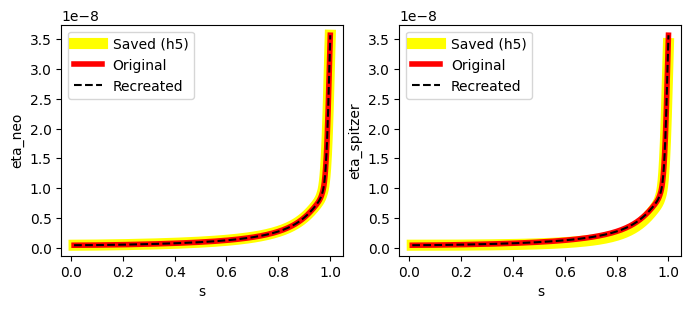

In [44]:
fig, axs = plt.subplots(1, 2,figsize=(8, 3))

axs[0].plot(data["s"], data["eta_neo"], label="Saved (h5)", lw=8, color="yellow")
axs[0].plot(original[0], original[1], label="Original", lw=4, color="red")
axs[0].plot(
    recreated[0], recreated[1], label="Recreated",
    lw=1.5, linestyle="--", color="black")
axs[0].set_xlabel("s")
axs[0].set_ylabel("eta_neo")
axs[0].legend()

axs[1].plot(data["s"], data["eta_spitzer"], label="Saved (h5)", lw=8, color="yellow")
axs[1].plot(original[0], original[1], label="Original", lw=4, color="red")
axs[1].plot(recreated[0], recreated[1], label="Recreated", lw=1.5, linestyle="--", color="black")
axs[1].set_xlabel("s")
axs[1].set_ylabel("eta_spitzer")
axs[1].legend()